# Changing $n$ and $p$

The binomial distribution has two main parameters:
* $n$: the number of trials (e.g., how many times we tossed the coin)
* $p$: the probability of a "hit"

Together these determine which together determine the probability of obtaining $k$ hits:

$$ k \sim \mathcal{B}(n,p) $$

What happens to the frequency of each value of k, if we change the probability of a hit ($p$), or the number of trials ($n$)? We'll explore this by sumulating binomial outcomes for different combinations of $n$ and $p$ and the plotting their distributions to see how the shape changes.


### Set up Python libraries

As usual, run the code cell below to import the relevant Python libraries

In [1]:
# Set-up Python libraries - you need to run this but you don't need to change it
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
import pandas as pd
import seaborn as sns
sns.set_theme(style='white')
import statsmodels.api as sm
import statsmodels.formula.api as smf
import warnings 
warnings.simplefilter('ignore', category=FutureWarning)

## $p$, probability of a hit

Think back to our home-baked code using randomly generated number $x$ between 0 and 1, with a probability $p$ of being a hit:

In [2]:
# check if it is less than p - this should happen on a proportion of trials equal to p
x = np.random.uniform(0,1)
p=0.5
if x>p:
    hit = 1
else:
    hit = 0
print(x)
print('is it a hit?:            ' + str(hit))

0.06216563699167976
is it a hit?:            0


If we change the value of $p$, this changes the *proportion* of our random $x$'s for which $x<p$ is true. The histograms below show the values of 10,000 outputs from `np.random.uniform()`, with those that match the criterion `x<p` highlighted in red

<img src= "https://raw.githubusercontent.com/jillxoreilly/StatsCourseBook_2024/main/images/Chp7_pvsx.png" width="95%"  />

* can you see why we used $x<p$ as a 'hit', rather than $x>p$?

When we use $x<p$, increasing $p$ makes the red region (and the proportion of hits) larger, which is exactly what we expect when the probability of a hit increases. If we used $x>p$ increasing $p$ would acutally correspond to increasing our probability of a *miss*. This is confusing, and unintuitive so we stick with $x<p$

### Distribution of $k$ depends on $p$

So far we've seen how changing $p$ affects the chance of a single hit. But how does it affect the distribution of $k$, where $k$ is the *number of hits* out of $n$ trials ($n$ coin tosses etc)?

Here is the code for the simulation again, now with $n$ and $p$ coded as variables rather than *hard coded* as 10 and 0.5


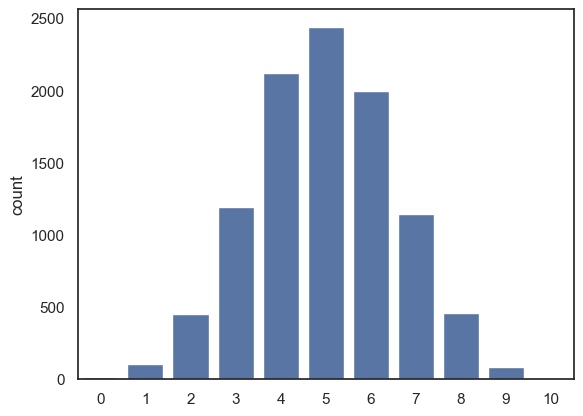

In [3]:
n=10
p=0.5
nReps = 10000

k = np.random.binomial(n,p, size=nReps)
    
sns.countplot(x=k) 
plt.show()

What if we change $p$ to be 0.7 instead?

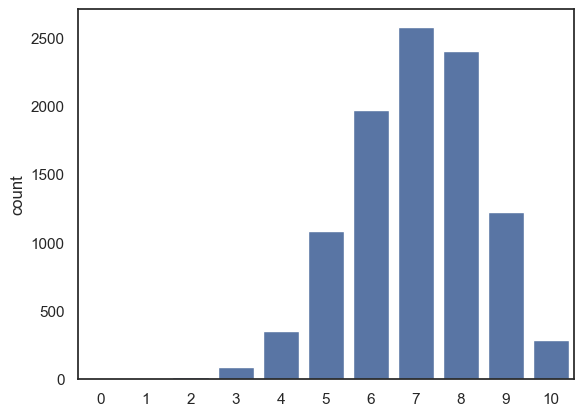

In [4]:
n=10
p=0.7
nReps = 10000

k = np.random.binomial(n,p, size=nReps)
    
sns.countplot(x=k, order=range(n+1)) 
# the argument 'order' is doing a similar job to 'bins' in a histogram
# here I am forcing sns to plot all the possible values of k from 0 to 10, 
# even though some of them didn't occur in the simulation
plt.show()

You should notice after modifying the simulation so that $p=0.7$:
* the most common value for k is 7, ie 7/10 hits.
* The distribution gets skewed, as we can't have more than 10/10 hits

Try some other values of $p$ to get a sense for how changing $p$ affects the distribution of $k$.

## Mean of $k$

The *expected value* of $k$, that is, the mean of $k$ over many repetitions, is represented as :

$$ E(k) = np $$

This tells us if we repeat the experiment many times, the average number of hits we get will be equal to the number of trials $n$ multipled by the probability of a hit $p$. 

In the following code block, we generate 10000 random samples from the binomial distribution $k \sim \mathcal{B}(n,p)$ and find their mean; we compare it to the value of the mean from the equation, $np$.

Hopefully it should match!

In [5]:
n=10
p=0.7
nReps = 10000

k = np.random.binomial(n,p, size=nReps)
    
print('mean(k) = ' + str(np.mean(k)))
print('n*p = ' + str(n*p))

mean(k) = 6.9906
n*p = 7.0


## $n$, number of trials

If we increase the number of trials to 100, what happens to the frequency distribution of $k$?

Here we modify the simulation so that $n=100$:

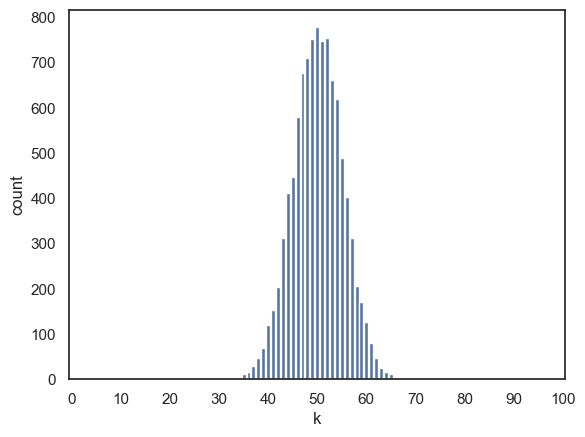

In [6]:
n=100
p=0.5
nReps = 10000

k = np.random.binomial(n,p, size=nReps)
    
sns.countplot(x=k, order=range(n+1)) 
# the argument 'order' is doing a similar job to 'bins' in a histogram
# here I am forcing sns to plot all the possible values of k from 0 to 100, 
# even though some of them didn't occur in the simulation

plt.xlabel('k')
plt.xticks(range(0, n+1, 10));

We can see that the peak of the histogram is where we expect (the most common value of $k$ is around 50, which matches the theoretical mean $np$). However, notice that the spread of the histogram is now narrower relative to the possible range of $k$ (i.e., from 0 to $n$) compared to when our value of $n was smaller.

In other words, as the number of trials increases, the propotion of hits (i.e., $k$/$n$) tends to stay closer to the expected probability $p$. The distribution of $k$ still grows in absolute wids (since the variance increases with $n$) but it becomes tighter in proportion to the total number of trials. This reflects the idea that the larger samples produce more stable averages. 


## Standard deviation of $k$

The standard deviation of $k$, that is, the typical amount of variation in the number of hits across many repetitions of our experiment is givent by: 

$$ std(k) = \sqrt{npq} $$

... where $q = (1-p)$

This formula tells us how much variability we should expect in the number of hits $k$ over repeated sets of $n$ trials. When $n$ is larger, the absolute spread of $k$ increases, but as a proportion of $n$, it becomes relatively smaller, meaning outcomes are more stable. 

In the following code block, we generate 10000 random samples from the binomial distribution $k \sim \mathcal{B}(n,p)$ and find their standard deviation; we compare it to the expected value of the standard deviation from the equation above. 

Hopefully it should match!

In [7]:
n=100
p=0.5
nReps = 10000

k = np.random.binomial(n,p, size=nReps)
    
print('std(k) = ' + str(k.std()))
print('sqrt(npq) = ' + str((n*p*(1-p))**0.5))

std(k) = 5.007494479278035
sqrt(npq) = 5.0


## Standard deviation of $k/n$

We noted above that that spread of the distribution of $k$, as a proportion of the range of possible values $(0-n)$ decreased as $n$ increased. 

In other words, when we have a larger number of trials the probability of observing unusually high or low proporition of hits purely by chance becomes smaller.

The proportion of hits is $k/n$ and its standard deviation (the expected variability in this proportion) is:

$$ \frac{\sqrt{pq}}{\sqrt{n}} $$

where $ q = (1-p) $

This has the interesting consequence that <b>for a given value of p, the standard deviation of the proportion of hits is proprtional to $\frac{1}{\sqrt(n)}$ </b>

In other words, as $n$ increases, the proportion of hits I observe in a single 'repetition' of the experiment (for example, one set of 10 coin tosses) conforms more closely to the true value of $p$, the probability of a hit - 

Put simply, our estimate of $p$ gets more accurate as we increase the number of trials, but the improvement follows a square-root law: the precision increases only in proportion to $\sqrt{n}$ (i.e., not linearly with $n$). 

Below, we will plot the propotion of hits for different sample sizes to see how our estimate of $p$ changes as a function of $n$. You will see that the spread becomes more narrow for larger values of$n$.

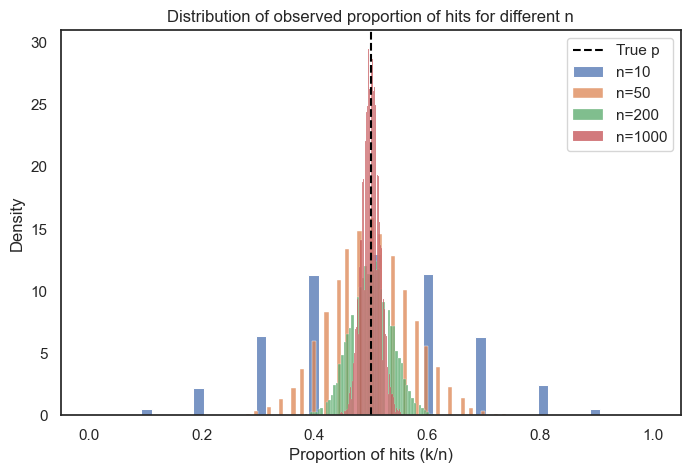

In [8]:
p    = 0.5           # probability of a hit
ns   = [10, 50, 200, 1000]  # different sample sizes to compare
size = 10000      # number of simulated experiments

plt.figure(figsize=(8, 5))

for n in ns:
    # simulate number of hits k for each experiment
    k = np.random.binomial(n, p, size=size)
    
    # calculate proportion of hits so that this remains on the same scale
    prop = k / n
    
    # plot histogram (as density) for each n
    sns.histplot(prop, label=f'n={n}', stat='density')

plt.axvline(p, color='black', linestyle='--', label='True p')
plt.xlabel('Proportion of hits (k/n)')
plt.ylabel('Density')
plt.title('Distribution of observed proportion of hits for different n')
plt.legend()
plt.show()